<a href="https://colab.research.google.com/github/itsSolG/sales-analysis-and-forecasting/blob/main/notebooks/02_sales_forecasting.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
#!git clone https://github.com/itsSolG/sales-analysis-and-forecasting.git

# **Sales Forecasting using Machine Learning**

## Objective

The goal of this notebook is to build a simple machine learning model to predict future sales based on historical data.

##Import Libraries

In this section, we import the necessary libraries for data manipulation and machine learning.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns
import os


##Data Loading

The dataset is loaded and the date column is converted into datetime format for time-based analysis.

In [3]:
df = pd.read_csv("data/superstore.csv")
df["Order Date"] = pd.to_datetime(df["Order.Date"])

##Feature Engineering
We extract the year and month from the order date to use them as numerical features for the model.

In [4]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

##**Inicial Model**

### Data Aggregation

Sales data is aggregated at a monthly level to simplify the time series and reduce noise.

In [5]:
monthly_sales = df.groupby(["Year", "Month"])["Sales"].sum().reset_index()
monthly_sales.head()

,Year,Month,Sales
0,2011,1,98902
1,2011,2,91152
2,2011,3,145726
3,2011,4,116927
4,2011,5,146762


### Define Variables

We define the input variables (features) and the target variable for the model.

In [6]:
X = monthly_sales[["Year", "Month"]]
y = monthly_sales["Sales"]

### Train-Test Split

The dataset is divided into training and testing sets to evaluate the model's performance.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

###Model Training
A linear regression model is trained to learn the relationship between time and sales.

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

###Predictions

In [9]:
predictions = model.predict(X_test)

#### Insight

A simple linear regression model was used to predict sales based on time (year and month). This provides a basic approach to understanding future sales trends.

###Model Evaluation

In [10]:
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 36793.82581278682


#### Model Insight

The model achieves a mean absolute error of approximately 36,793, indicating that predictions deviate from actual sales by this amount on average.

Considering the scale of monthly sales, this level of error suggests that the model captures general trends but lacks precision for accurate forecasting. This is expected given the simplicity of the linear regression model and the limited number of features used.

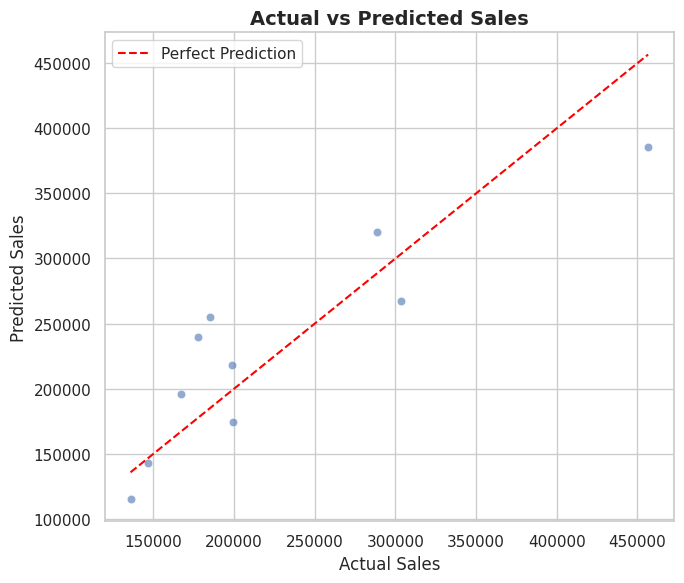

In [11]:
sns.set(style="whitegrid")
plt.figure(figsize=(7,6))

sns.scatterplot(
    x=y_test,
    y=predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Sales", fontsize=14, weight='bold')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.legend()

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig("images/forecast_scatter.png", dpi=300)

plt.show()

#### Model Insight

The scatter plot shows a high level of dispersion between actual and predicted values, indicating that the model struggles to accurately capture sales behavior.

While the model is able to reflect general trends, it lacks the complexity needed to account for variability in the data. This suggests that additional features and more advanced models would be required to improve prediction accuracy.

## **Model Improvement (Inicial Attempt)**
In an effort to improve the model, additional features such as product category and quantity were included to provide more context about sales behavior.

These features are expected to enhance the model’s ability to capture patterns beyond simple time-based trends.

In [ ]:
df_model = df[["Sales", "Quantity", "Category"]]
df_model.head()

,Sales,Quantity,Category
0,19,3,Office Supplies
1,19,2,Office Supplies
2,21,3,Office Supplies
3,111,2,Office Supplies
4,6,1,Office Supplies


###Feature Engineering

In [ ]:
df_encoded = pd.get_dummies(df_model, columns = ["Category"], drop_first = True)

###Define Variables

In [ ]:
X = df_encoded.drop("Sales", axis = 1)
y = df_encoded["Sales"]

### Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

###Model Training

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

###Predictions

In [ ]:
predictions = model.predict(X_test)

###Model Evaluation

In [ ]:
mae = mean_absolute_error(y_test, predictions)
print("New MAE:", mae)

New MAE: 213.6153325198142


### Model Improvement Insight

The improved model shows a significantly lower error compared to the initial model. However, this improvement is largely due to the inclusion of features such as quantity, which are directly correlated with sales.

This introduces a form of data leakage, where the model has access to information that strongly determines the target variable, leading to overly optimistic performance.

While the model appears highly accurate, its predictive capability in real-world scenarios may be limited.

## **Model Refinement (Without Data Leakage)**
To address the issue of data leakage observed in the previous model, features that are directly correlated with the target variable were removed.

In this case, the quantity variable was excluded, and the model was rebuilt using only time-based and categorical features. This adjustment aims to produce a more realistic and reliable prediction model.

In [5]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

###Data Agregation

In [6]:
df_model = df[["Sales", "Year", "Month", "Category"]]

###Feature Encoding

In [7]:
df_encoded = pd.get_dummies(df_model, columns=["Category"], drop_first=True)

In [8]:
X = df_encoded.drop("Sales", axis=1)
y = df_encoded["Sales"]

###Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###Model Training

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

###Predictions

In [11]:
predictions = model.predict(X_test)

###Model Evaluation

In [12]:
mae = mean_absolute_error(y_test, predictions)
print("Refined MAE:", mae)

Refined MAE: 225.07875054294252


### Model Insight

After removing the quantity feature, the model maintains a low prediction error, similar to the previous improvement. However, this result remains misleading.

The model is still trained on transaction-level data, which introduces patterns that are too granular and repetitive. This allows the model to achieve artificially good performance without truly capturing broader sales behavior.

Therefore, despite the low error, the model is not fully reliable for realistic forecasting purposes.

##**Final Model (Aggregated Data)**

To build a more realistic and reliable forecasting model, the dataset was restructured by aggregating sales at a monthly level and by category.

This approach aligns the modeling process with the business context, where decisions are typically made based on summarized trends rather than individual transactions.

By grouping the data by year, month, and category, the model reduces noise, avoids repetitive patterns, and minimizes the risk of misleading performance caused by overly granular data.

This final model provides a more accurate representation of sales behavior over time and offers a better foundation for forecasting.

###Data Aggregation
Sales data was grouped by year, month, and category to create a structured time-based dataset.  
This reduces variability and aligns the data with real business reporting.


In [5]:
monthly_sales = df.groupby(["Year", "Month", "Category"])["Sales"].sum().reset_index()

###Feature Encoding
The category variable was transformed into numerical format using one-hot encoding to make it compatible with machine learning algorithms.


In [6]:
monthly_encoded = pd.get_dummies(monthly_sales, columns=["Category"], drop_first=True)

###Feature and Target Definition
Input variables (year, month, and category) were used to predict total monthly sales.


In [7]:
X = monthly_encoded.drop("Sales", axis=1)
y = monthly_encoded["Sales"]

###Train-Test Split
The dataset was divided into training and testing sets to evaluate model performance on unseen data.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###Model Training
A linear regression model was trained to learn the relationship between time, category, and sales.


In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

###Predictions

In [10]:
predictions = model.predict(X_test)

###Model Evaluation

In [11]:
mae = mean_absolute_error(y_test, predictions)
print("Final MAE:", mae)

Final MAE: 16484.401765179788


### Model Insight

The final model provides a more realistic estimation of sales compared to previous approaches.

Although the prediction error is higher than earlier models, this result is more reliable because it avoids data leakage and reduces the impact of highly granular transaction data.

By using aggregated monthly data, the model focuses on general trends rather than memorizing patterns, making it more suitable for real-world forecasting scenarios.

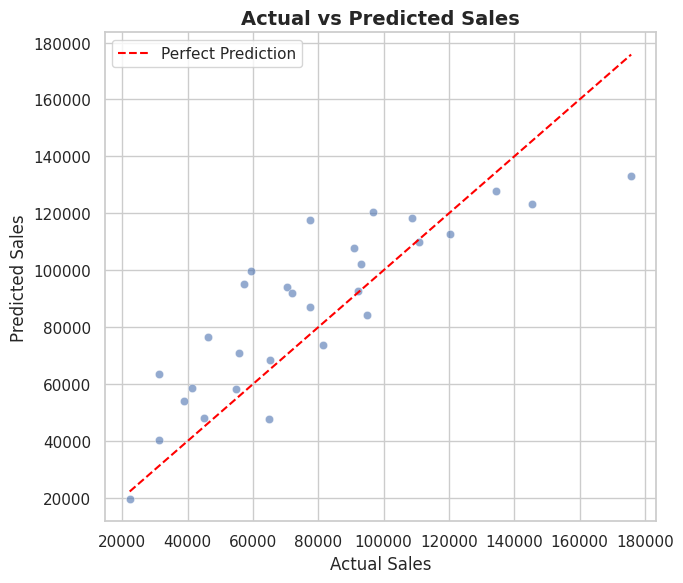

In [12]:
sns.set(style="whitegrid")
plt.figure(figsize=(7,6))

sns.scatterplot(
    x=y_test,
    y=predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Sales", fontsize=14, weight='bold')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.legend()

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig("images/forecast_scatter.png", dpi=300)

plt.show()

The scatter plot shows a clear positive relationship between actual and predicted sales, indicating that the model successfully captures the overall trend in the data.

Most points are distributed close to the diagonal line, which suggests that the predictions are reasonably accurate for a large portion of the dataset.

However, there is noticeable dispersion, especially at higher sales values, where the model tends to underestimate actual sales. This suggests that the model struggles to accurately predict extreme or high-value cases.

Overall, the model provides a solid baseline for understanding sales behavior, but its performance could be improved by incorporating additional features or more advanced modeling techniques.

## Conclusion
This project explored sales performance using the Global Superstore dataset through both exploratory analysis and machine learning. This notebook focused on building and evaluating machine learning models for sales prediction.

Different approaches were tested, revealing that initial models produced overly optimistic results due to data leakage and the use of highly granular data. After refining the approach, a final model based on aggregated monthly data provided more realistic and reliable predictions.

This process highlights the importance of proper feature selection, data structure, and critical evaluation when developing machine learning models.
